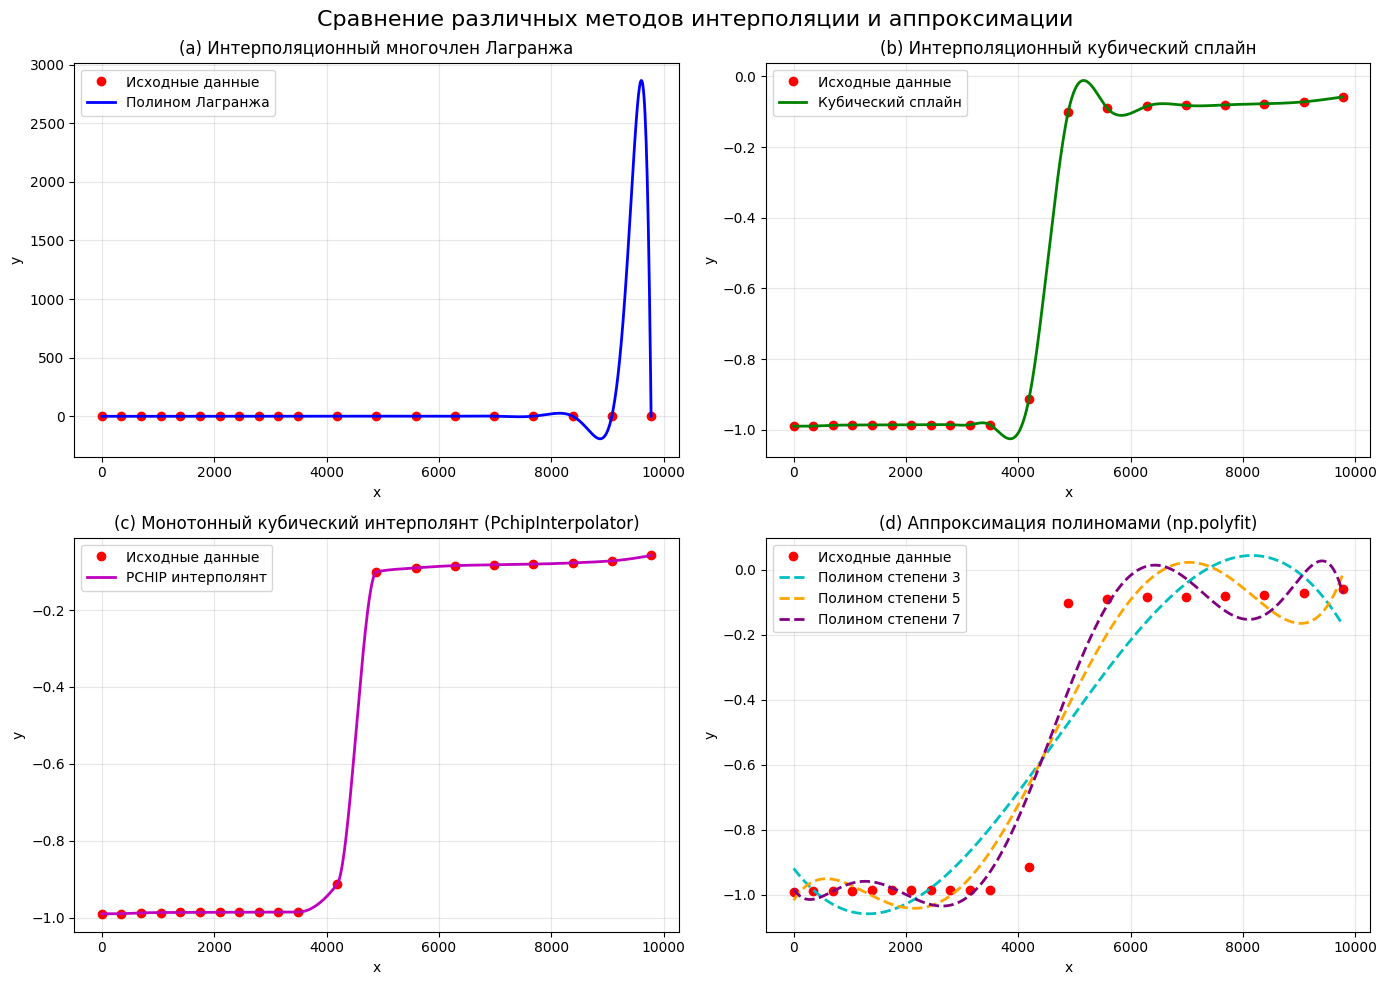

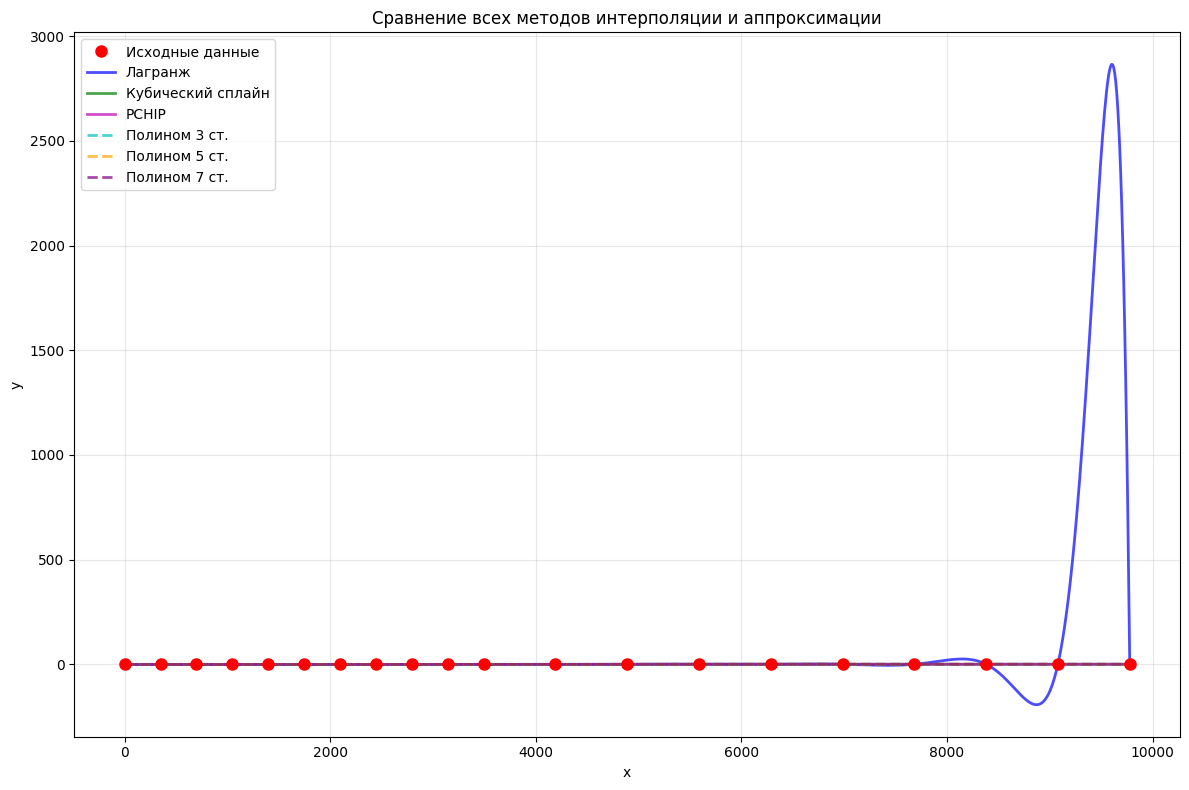

Количество точек данных: 20
Диапазон x: [0.000, 9778.000]
Диапазон y: [-0.990, -0.058]


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator

# Загрузка данных из архива
with np.load('data_interp.npz') as data:
    x1, y1 = data['x1'], data['y1']

# Создание более плотной сетки для гладкого отображения функций
x_dense = np.linspace(min(x1), max(x1), 1000)

# (a) Интерполяционный многочлен Лагранжа
def lagrange_interpolation(x, y, x_eval):
    """Вычисление интерполяционного многочлена Лагранжа в точках x_eval"""
    n = len(x)
    result = np.zeros_like(x_eval, dtype=float)
    
    for i in range(n):
        # Вычисление базисного полинома Li
        li = np.ones_like(x_eval)
        for j in range(n):
            if i != j:
                li *= (x_eval - x[j]) / (x[i] - x[j])
        result += y[i] * li
    
    return result

# Вычисление значений полинома Лагранжа
y_lagrange = lagrange_interpolation(x1, y1, x_dense)

# (b) Интерполяционный кубический сплайн
cs = CubicSpline(x1, y1, bc_type='natural')  # natural boundary conditions
y_spline = cs(x_dense)

# (c) Монотонный кубический интерполянт
pchip = PchipInterpolator(x1, y1)
y_pchip = pchip(x_dense)

# (d) Аппроксимация полиномами разных степеней
degrees = [3, 5, 7]  # можно изменить степени полиномов
poly_fits = {}

for deg in degrees:
    coeffs = np.polyfit(x1, y1, deg)
    y_fit = np.polyval(coeffs, x_dense)
    poly_fits[deg] = y_fit

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение различных методов интерполяции и аппроксимации', fontsize=16)

# (a) Полином Лагранжа
ax1 = axes[0, 0]
ax1.plot(x1, y1, 'ro', label='Исходные данные', markersize=6)
ax1.plot(x_dense, y_lagrange, 'b-', label='Полином Лагранжа', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('(a) Интерполяционный многочлен Лагранжа')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (b) Кубический сплайн
ax2 = axes[0, 1]
ax2.plot(x1, y1, 'ro', label='Исходные данные', markersize=6)
ax2.plot(x_dense, y_spline, 'g-', label='Кубический сплайн', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('(b) Интерполяционный кубический сплайн')
ax2.legend()
ax2.grid(True, alpha=0.3)

# (c) Монотонный кубический интерполянт
ax3 = axes[1, 0]
ax3.plot(x1, y1, 'ro', label='Исходные данные', markersize=6)
ax3.plot(x_dense, y_pchip, 'm-', label='PCHIP интерполянт', linewidth=2)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('(c) Монотонный кубический интерполянт (PchipInterpolator)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# (d) Аппроксимация полиномами
ax4 = axes[1, 1]
ax4.plot(x1, y1, 'ro', label='Исходные данные', markersize=6)

colors = ['c', 'orange', 'purple']
for i, (deg, y_fit) in enumerate(poly_fits.items()):
    ax4.plot(x_dense, y_fit, color=colors[i], 
             label=f'Полином степени {deg}', linewidth=2, linestyle='--')

ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('(d) Аппроксимация полиномами (np.polyfit)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: сравнение всех методов на одном графике
plt.figure(figsize=(12, 8))
plt.plot(x1, y1, 'ro', label='Исходные данные', markersize=8, zorder=5)
plt.plot(x_dense, y_lagrange, 'b-', label='Лагранж', linewidth=2, alpha=0.7)
plt.plot(x_dense, y_spline, 'g-', label='Кубический сплайн', linewidth=2, alpha=0.7)
plt.plot(x_dense, y_pchip, 'm-', label='PCHIP', linewidth=2, alpha=0.7)

for i, (deg, y_fit) in enumerate(poly_fits.items()):
    plt.plot(x_dense, y_fit, '--', color=colors[i], 
             label=f'Полином {deg} ст.', linewidth=2, alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение всех методов интерполяции и аппроксимации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод информации о данных
print(f"Количество точек данных: {len(x1)}")
print(f"Диапазон x: [{min(x1):.3f}, {max(x1):.3f}]")
print(f"Диапазон y: [{min(y1):.3f}, {max(y1):.3f}]")

# Задача 2

In [45]:
import numpy as np

class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """

    def _lagrange_interpolation_(x, y, x_eval):
        """Вычисление интерполяционного многочлена Лагранжа в точках x_eval"""
        n = len(x)
        result = np.zeros_like(x_eval, dtype=float)
        
        for i in range(n):
            # Вычисление базисного полинома Li
            li = np.ones_like(x_eval)
            for j in range(n):
                if i != j:
                    li *= (x_eval - x[j]) / (x[i] - x[j])
            result += y[i] * li
            return result

    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)

        

    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """
        n = len(self.xk)
        result = 0.0
        for i in range(n):
            # Вычисление базисного полинома Li
            li=1.0
            for j in range(n):
                if i != j:
                    li *= (x - self.xk[j]) / (self.xk[i] - self.xk[j])
            result += self.yk[i] * li
        return result


In [46]:
def runge_func(x, a=25):
    return 1.0 / (1.0 + a*x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)


from numpy.testing import assert_allclose

assert_allclose(yy,
                [lagr(xval) for xval in xx],
                atol=1e-14)

# Задача 3

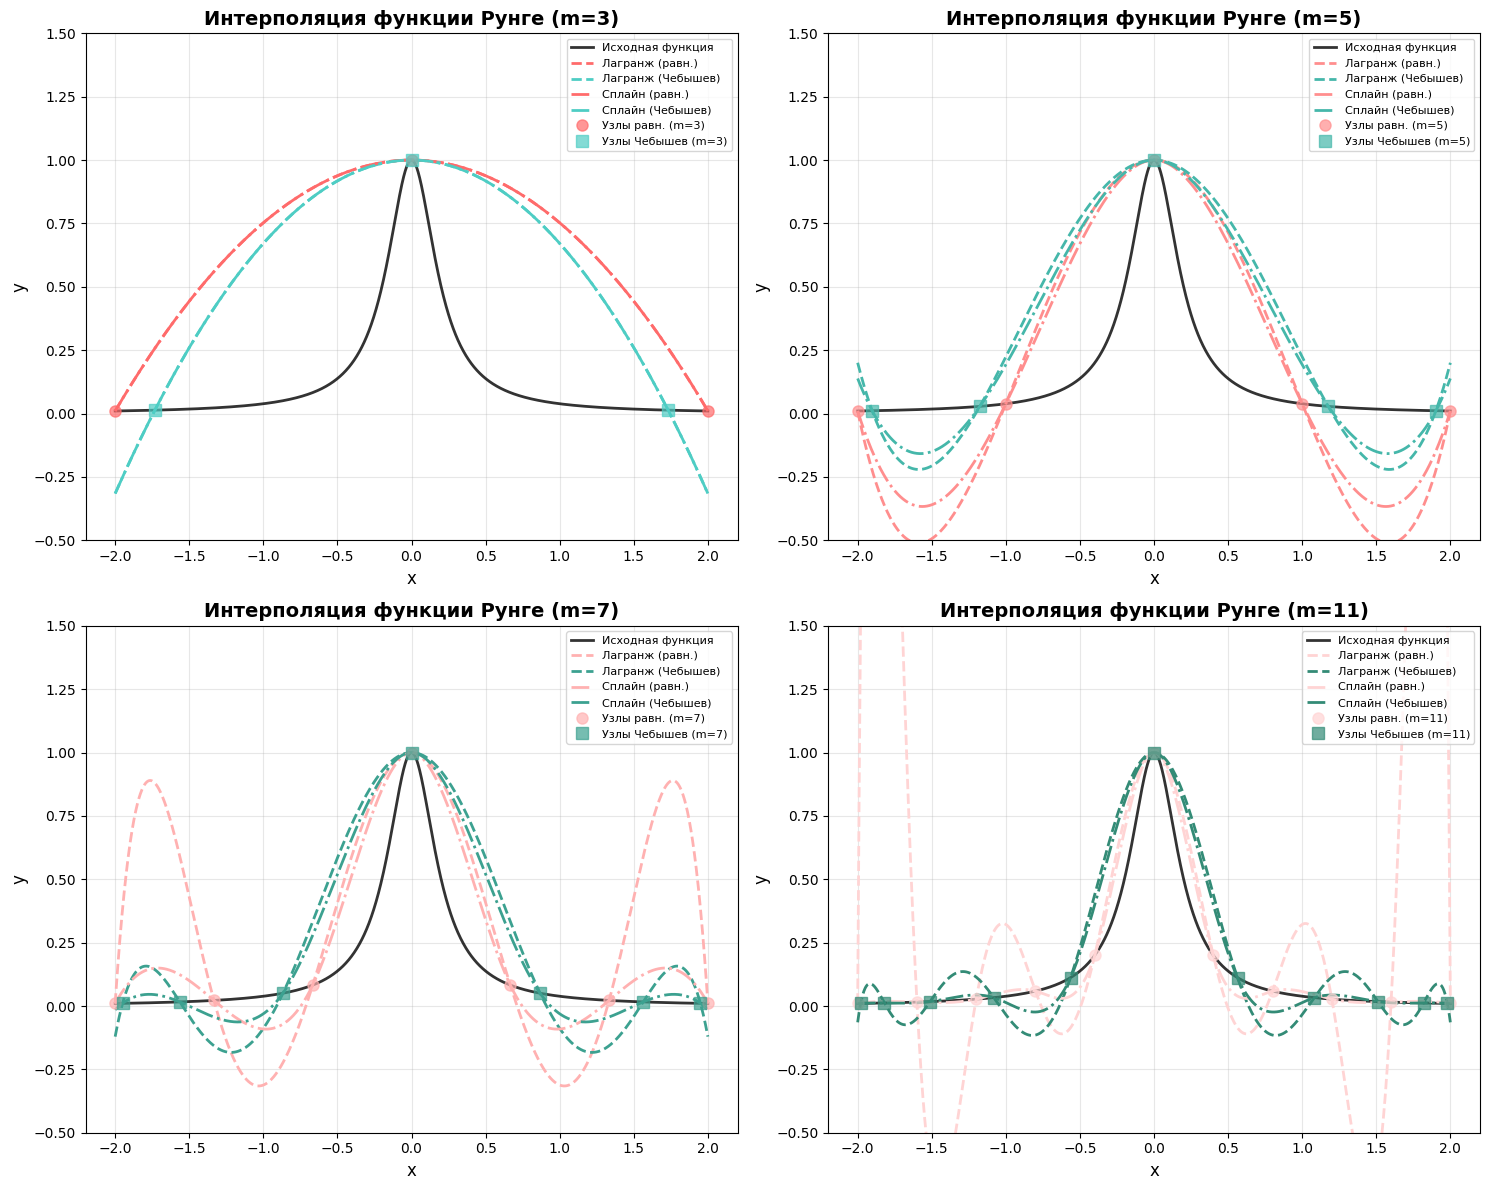

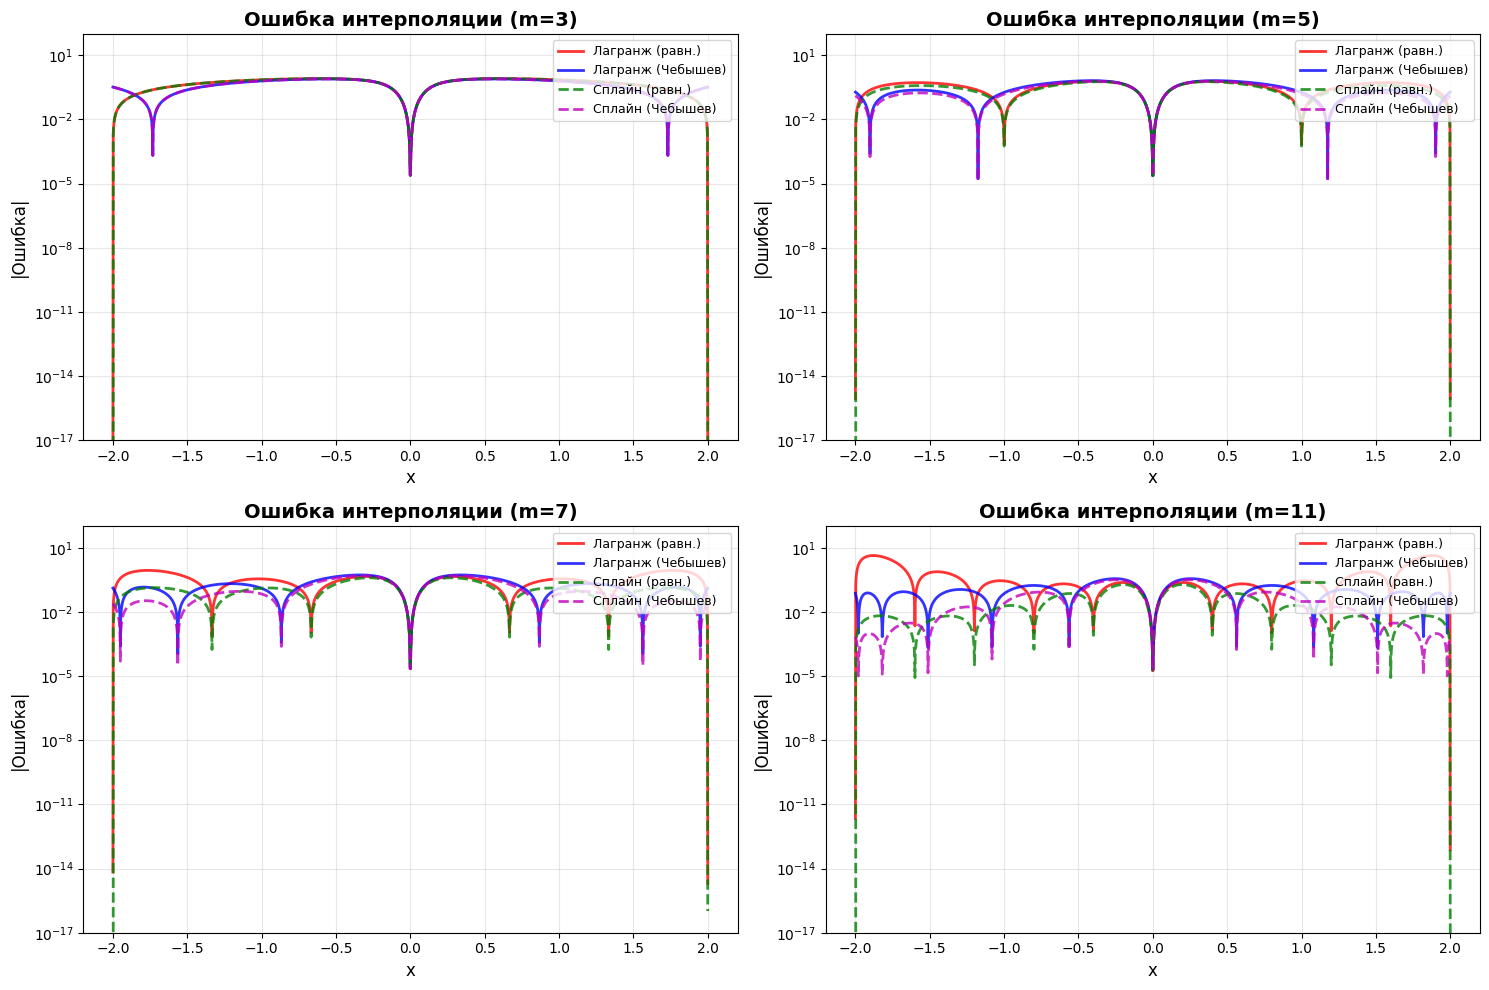

МАКСИМАЛЬНЫЕ ОШИБКИ ИНТЕРПОЛЯЦИИ ФУНКЦИИ РУНГЕ НА [-2, 2]
m     Метод                Макс. ошибка    Относительная ошибка
--------------------------------------------------------------------------------

3     Лагранж (равн.)     8.11e-01        8.11e-01            
      Лагранж (Чебышев)  7.84e-01        7.84e-01            
      Сплайн (равн.)      8.11e-01        8.11e-01            
      Сплайн (Чебышев)    7.84e-01        7.84e-01            

5     Лагранж (равн.)     6.15e-01        6.15e-01            
      Лагранж (Чебышев)  6.50e-01        6.50e-01            
      Сплайн (равн.)      5.81e-01        5.81e-01            
      Сплайн (Чебышев)    6.14e-01        6.14e-01            

7     Лагранж (равн.)     8.77e-01        8.77e-01            
      Лагранж (Чебышев)  5.37e-01        5.37e-01            
      Сплайн (равн.)      3.96e-01        3.96e-01            
      Сплайн (Чебышев)    4.90e-01        4.90e-01            

11    Лагранж (равн.)     4.34e+00      

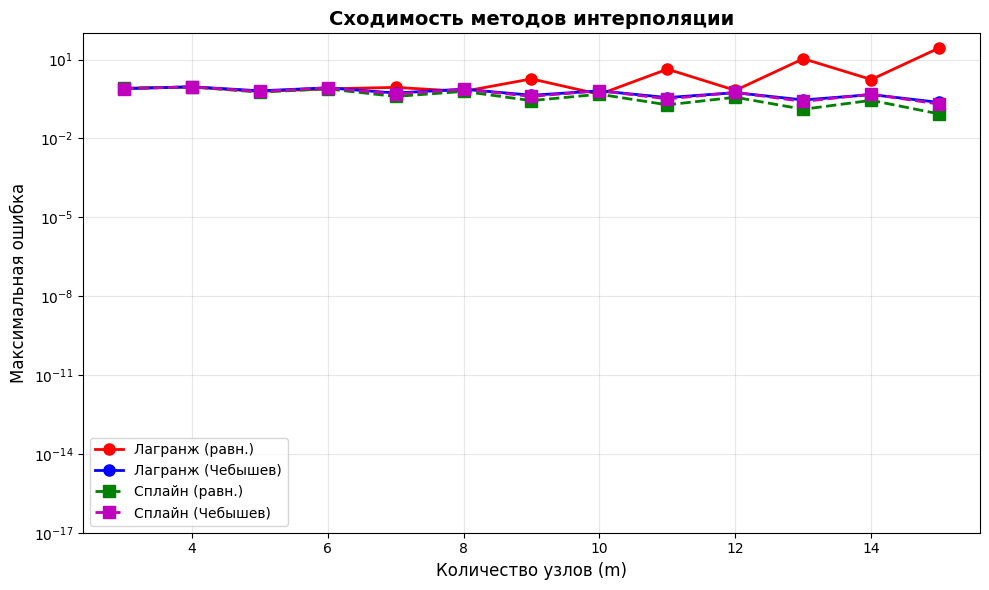

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline
import warnings
warnings.filterwarnings('ignore')  # Игнорируем предупреждения о переполнении

# Определение функции Рунге
def runge(x):
    return 1 / (1 + 25 * x**2)

# Интервал
a, b = -2, 2
x_plot = np.linspace(a, b, 2000)
y_true = runge(x_plot)

# Количество узлов для исследования
m_values = [3, 5, 7, 11]

# Создание фигуры с подграфиками
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Цвета для разных методов
colors_lagrange = ['#FF6B6B', '#FF8E8E', '#FFB1B1', '#FFD4D4']
colors_spline = ['#4ECDC4', '#45B7AA', '#3CA190', '#338B76']

for idx, m in enumerate(m_values):
    ax = axes[idx]
    
    # Равномерная сетка
    x_uniform = np.linspace(a, b, m)
    y_uniform = runge(x_uniform)
    
    # Чебышевская сетка
    def cheb_nodes(n, a, b):
        k = np.arange(1, n+1)
        nodes_std = np.cos((2*k - 1) * np.pi / (2*n))
        nodes = (a + b)/2 + (b - a)/2 * nodes_std
        return np.sort(nodes)
    
    x_cheb = cheb_nodes(m, a, b)
    y_cheb = runge(x_cheb)
    
    # Полином Лагранжа для равномерной сетки
    try:
        p_lagrange_uniform = lagrange(x_uniform, y_uniform)
        y_lagrange_uniform = p_lagrange_uniform(x_plot)
    except:
        y_lagrange_uniform = np.full_like(x_plot, np.nan)
    
    # Полином Лагранжа для чебышевской сетки
    try:
        p_lagrange_cheb = lagrange(x_cheb, y_cheb)
        y_lagrange_cheb = p_lagrange_cheb(x_plot)
    except:
        y_lagrange_cheb = np.full_like(x_plot, np.nan)
    
    # Кубический сплайн для равномерной сетки
    cs_uniform = CubicSpline(x_uniform, y_uniform)
    y_spline_uniform = cs_uniform(x_plot)
    
    # Кубический сплайн для чебышевской сетки
    cs_cheb = CubicSpline(x_cheb, y_cheb)
    y_spline_cheb = cs_cheb(x_plot)
    
    # Построение графиков
    ax.plot(x_plot, y_true, 'k-', label='Исходная функция', linewidth=2, alpha=0.8)
    ax.plot(x_plot, y_lagrange_uniform, '--', color=colors_lagrange[idx], 
            label=f'Лагранж (равн.)', linewidth=2)
    ax.plot(x_plot, y_lagrange_cheb, '--', color=colors_spline[idx], 
            label=f'Лагранж (Чебышев)', linewidth=2)
    ax.plot(x_plot, y_spline_uniform, '-.', color=colors_lagrange[idx], 
            label=f'Сплайн (равн.)', linewidth=2)
    ax.plot(x_plot, y_spline_cheb, '-.', color=colors_spline[idx], 
            label=f'Сплайн (Чебышев)', linewidth=2)
    
    # Отмечаем узлы
    ax.plot(x_uniform, y_uniform, 'o', color=colors_lagrange[idx], 
            markersize=8, label=f'Узлы равн. (m={m})', alpha=0.7)
    ax.plot(x_cheb, y_cheb, 's', color=colors_spline[idx], 
            markersize=8, label=f'Узлы Чебышев (m={m})', alpha=0.7)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'Интерполяция функции Рунге (m={m})', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.5, 1.5])  # Фиксируем пределы по y для лучшего сравнения

plt.tight_layout()
plt.show()

# Создание отдельного графика для сравнения ошибок
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, m in enumerate(m_values):
    ax = axes[idx]
    
    x_uniform = np.linspace(a, b, m)
    y_uniform = runge(x_uniform)
    x_cheb = cheb_nodes(m, a, b)
    y_cheb = runge(x_cheb)
    
    # Вычисляем интерполянты
    p_lagrange_uniform = lagrange(x_uniform, y_uniform)
    p_lagrange_cheb = lagrange(x_cheb, y_cheb)
    cs_uniform = CubicSpline(x_uniform, y_uniform)
    cs_cheb = CubicSpline(x_cheb, y_cheb)
    
    y_lagrange_uniform = p_lagrange_uniform(x_plot)
    y_lagrange_cheb = p_lagrange_cheb(x_plot)
    y_spline_uniform = cs_uniform(x_plot)
    y_spline_cheb = cs_cheb(x_plot)
    
    # Вычисляем ошибки
    error_lagrange_uniform = np.abs(y_true - y_lagrange_uniform)
    error_lagrange_cheb = np.abs(y_true - y_lagrange_cheb)
    error_spline_uniform = np.abs(y_true - y_spline_uniform)
    error_spline_cheb = np.abs(y_true - y_spline_cheb)
    
    # Логарифмическая шкала для ошибок
    ax.semilogy(x_plot, error_lagrange_uniform, 'r-', label='Лагранж (равн.)', linewidth=2, alpha=0.8)
    ax.semilogy(x_plot, error_lagrange_cheb, 'b-', label='Лагранж (Чебышев)', linewidth=2, alpha=0.8)
    ax.semilogy(x_plot, error_spline_uniform, 'g--', label='Сплайн (равн.)', linewidth=2, alpha=0.8)
    ax.semilogy(x_plot, error_spline_cheb, 'm--', label='Сплайн (Чебышев)', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('|Ошибка|', fontsize=12)
    ax.set_title(f'Ошибка интерполяции (m={m})', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_ylim([1e-17, 1e2])

plt.tight_layout()
plt.show()

# Таблица с максимальными ошибками
print("=" * 80)
print("МАКСИМАЛЬНЫЕ ОШИБКИ ИНТЕРПОЛЯЦИИ ФУНКЦИИ РУНГЕ НА [-2, 2]")
print("=" * 80)
print(f"{'m':<5} {'Метод':<20} {'Макс. ошибка':<15} {'Относительная ошибка':<20}")
print("-" * 80)

for m in m_values:
    x_uniform = np.linspace(a, b, m)
    y_uniform = runge(x_uniform)
    x_cheb = cheb_nodes(m, a, b)
    y_cheb = runge(x_cheb)
    
    # Вычисляем интерполянты
    p_lagrange_uniform = lagrange(x_uniform, y_uniform)
    p_lagrange_cheb = lagrange(x_cheb, y_cheb)
    cs_uniform = CubicSpline(x_uniform, y_uniform)
    cs_cheb = CubicSpline(x_cheb, y_cheb)
    
    y_lagrange_uniform = p_lagrange_uniform(x_plot)
    y_lagrange_cheb = p_lagrange_cheb(x_plot)
    y_spline_uniform = cs_uniform(x_plot)
    y_spline_cheb = cs_cheb(x_plot)
    
    # Вычисляем ошибки
    max_error_lagrange_uniform = np.max(np.abs(y_true - y_lagrange_uniform))
    max_error_lagrange_cheb = np.max(np.abs(y_true - y_lagrange_cheb))
    max_error_spline_uniform = np.max(np.abs(y_true - y_spline_uniform))
    max_error_spline_cheb = np.max(np.abs(y_true - y_spline_cheb))
    
    # Относительные ошибки
    rel_error_lagrange_uniform = max_error_lagrange_uniform / np.max(np.abs(y_true))
    rel_error_lagrange_cheb = max_error_lagrange_cheb / np.max(np.abs(y_true))
    rel_error_spline_uniform = max_error_spline_uniform / np.max(np.abs(y_true))
    rel_error_spline_cheb = max_error_spline_cheb / np.max(np.abs(y_true))
    
    print(f"\n{m:<5} Лагранж (равн.)     {max_error_lagrange_uniform:<15.2e} {rel_error_lagrange_uniform:<20.2e}")
    print(f"{'':<5} Лагранж (Чебышев)  {max_error_lagrange_cheb:<15.2e} {rel_error_lagrange_cheb:<20.2e}")
    print(f"{'':<5} Сплайн (равн.)      {max_error_spline_uniform:<15.2e} {rel_error_spline_uniform:<20.2e}")
    print(f"{'':<5} Сплайн (Чебышев)    {max_error_spline_cheb:<15.2e} {rel_error_spline_cheb:<20.2e}")

print("=" * 80)

# Визуализация сходимости
fig, ax = plt.subplots(figsize=(10, 6))

errors_lagrange_uniform = []
errors_lagrange_cheb = []
errors_spline_uniform = []
errors_spline_cheb = []

for m in range(3, 16):
    x_uniform = np.linspace(a, b, m)
    y_uniform = runge(x_uniform)
    x_cheb = cheb_nodes(m, a, b)
    y_cheb = runge(x_cheb)
    
    p_lagrange_uniform = lagrange(x_uniform, y_uniform)
    p_lagrange_cheb = lagrange(x_cheb, y_cheb)
    cs_uniform = CubicSpline(x_uniform, y_uniform)
    cs_cheb = CubicSpline(x_cheb, y_cheb)
    
    errors_lagrange_uniform.append(np.max(np.abs(y_true - p_lagrange_uniform(x_plot))))
    errors_lagrange_cheb.append(np.max(np.abs(y_true - p_lagrange_cheb(x_plot))))
    errors_spline_uniform.append(np.max(np.abs(y_true - cs_uniform(x_plot))))
    errors_spline_cheb.append(np.max(np.abs(y_true - cs_cheb(x_plot))))

m_range = range(3, 16)
ax.semilogy(m_range, errors_lagrange_uniform, 'ro-', label='Лагранж (равн.)', linewidth=2, markersize=8)
ax.semilogy(m_range, errors_lagrange_cheb, 'bo-', label='Лагранж (Чебышев)', linewidth=2, markersize=8)
ax.semilogy(m_range, errors_spline_uniform, 'gs--', label='Сплайн (равн.)', linewidth=2, markersize=8)
ax.semilogy(m_range, errors_spline_cheb, 'ms--', label='Сплайн (Чебышев)', linewidth=2, markersize=8)

ax.set_xlabel('Количество узлов (m)', fontsize=12)
ax.set_ylabel('Максимальная ошибка', fontsize=12)
ax.set_title('Сходимость методов интерполяции', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim([1e-17, 1e2])

plt.tight_layout()
plt.show()

# Задача 4

Теоретически оптимальное s = 2.0000


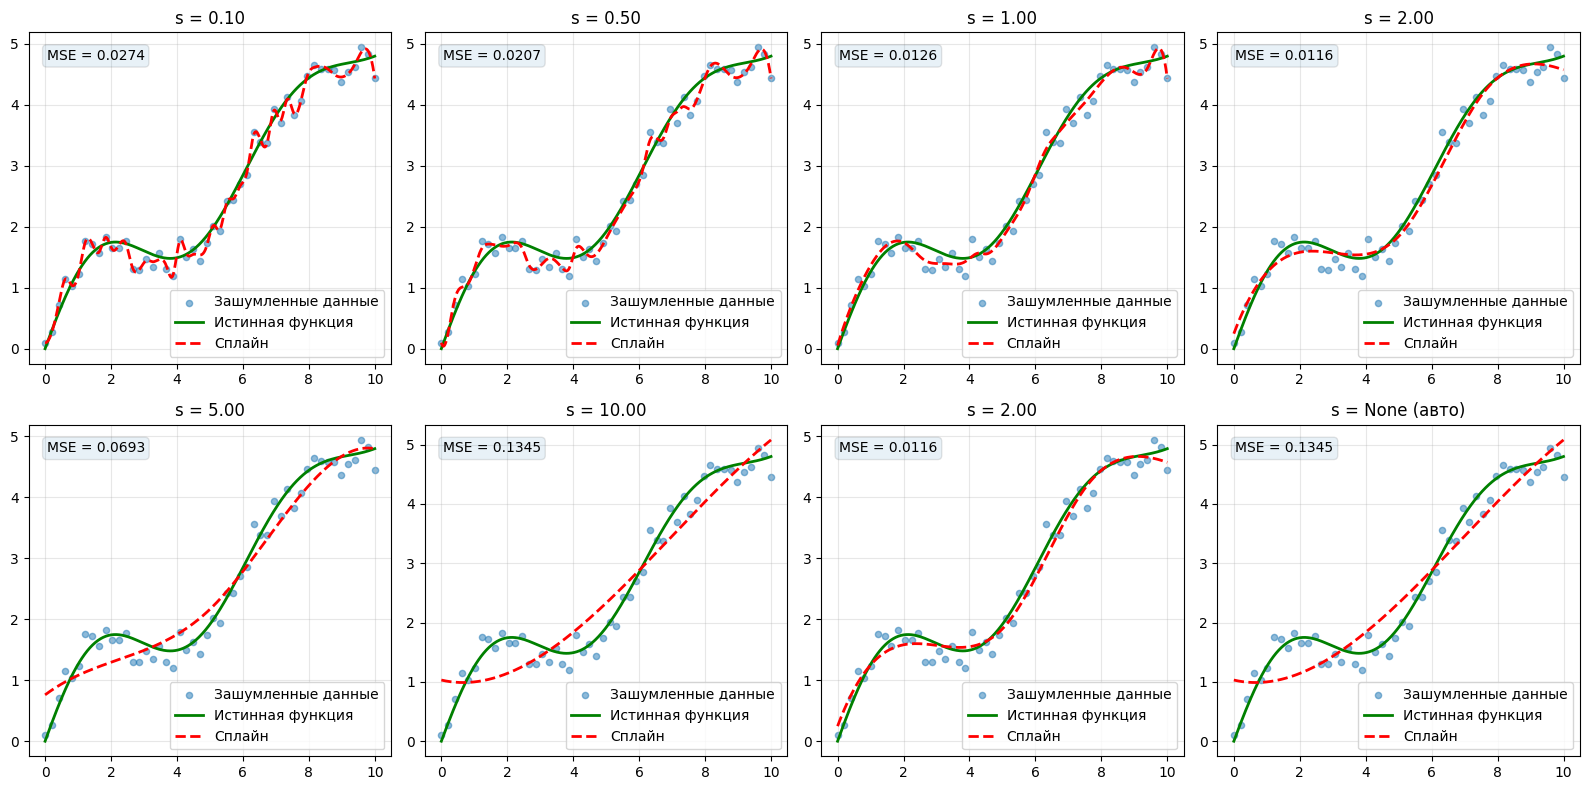

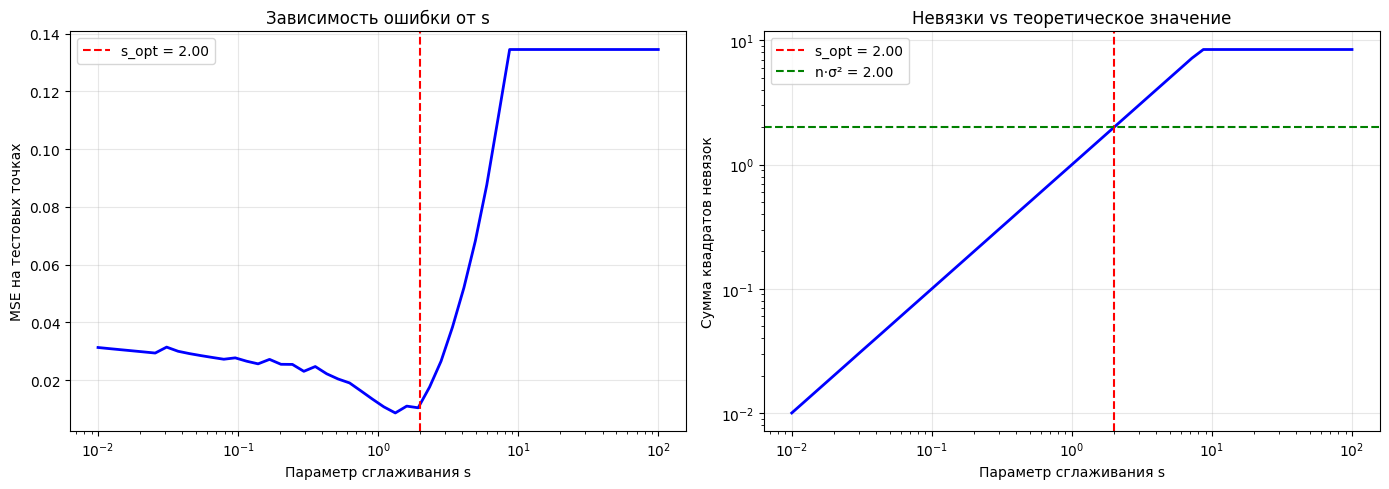


Оптимальное s по теории: 2.0000
Оптимальное s по кросс-валидации: 1.1721


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Создаем тестовую функцию
def true_function(x):
    return np.sin(x) * np.exp(-0.1 * x) + 0.5 * x

# Генерируем данные с шумом
np.random.seed(42)
n_points = 50
x = np.linspace(0, 10, n_points)
y_true = true_function(x)

# Добавляем шум с известной дисперсией
sigma = 0.2
noise = np.random.normal(0, sigma, n_points)
y_noisy = y_true + noise

# Теоретически оптимальное значение s
s_optimal = n_points * sigma**2
print(f"Теоретически оптимальное s = {s_optimal:.4f}")

# Создаем сплайны с разными значениями s
s_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, s_optimal]
splines = []
titles = []

for s in s_values:
    spline = UnivariateSpline(x, y_noisy, s=s)
    splines.append(spline)
    titles.append(f's = {s:.2f}')

# Добавляем сплайн с автоматическим выбором s
spline_auto = UnivariateSpline(x, y_noisy)
splines.append(spline_auto)
titles.append('s = None (авто)')

# Визуализация
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

x_fine = np.linspace(0, 10, 500)

for i, (spline, title) in enumerate(zip(splines, titles)):
    ax = axes[i]
    ax.scatter(x, y_noisy, alpha=0.5, s=20, label='Зашумленные данные')
    ax.plot(x_fine, true_function(x_fine), 'g-', linewidth=2, label='Истинная функция')
    ax.plot(x_fine, spline(x_fine), 'r--', linewidth=2, label='Сплайн')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Вычисляем MSE на тестовых точках
    mse = np.mean((spline(x_fine) - true_function(x_fine))**2)
    ax.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

# Убираем лишний subplot
if len(splines) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Анализ качества для разных s
s_range = np.logspace(-2, 2, 50)
mse_values = []
residuals = []

for s in s_range:
    spline = UnivariateSpline(x, y_noisy, s=s)
    mse = np.mean((spline(x_fine) - true_function(x_fine))**2)
    mse_values.append(mse)
    
    # Вычисляем сумму квадратов невязок
    residual = np.sum((y_noisy - spline(x))**2)
    residuals.append(residual)

# Визуализация зависимости качества от s
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MSE от s
ax1.semilogx(s_range, mse_values, 'b-', linewidth=2)
ax1.axvline(s_optimal, color='r', linestyle='--', 
            label=f's_opt = {s_optimal:.2f}')
ax1.set_xlabel('Параметр сглаживания s')
ax1.set_ylabel('MSE на тестовых точках')
ax1.set_title('Зависимость ошибки от s')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Невязки от s
ax2.loglog(s_range, residuals, 'b-', linewidth=2)
ax2.axvline(s_optimal, color='r', linestyle='--', 
            label=f's_opt = {s_optimal:.2f}')
ax2.axhline(n_points * sigma**2, color='g', linestyle='--', 
            label=f'n·σ² = {n_points * sigma**2:.2f}')
ax2.set_xlabel('Параметр сглаживания s')
ax2.set_ylabel('Сумма квадратов невязок')
ax2.set_title('Невязки vs теоретическое значение')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение с кросс-валидацией
from sklearn.model_selection import KFold

def cv_score(s, x, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    errors = []
    
    for train_idx, val_idx in kf.split(x):
        x_train, x_val = x[train_idx], x[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        spline = UnivariateSpline(x_train, y_train, s=s)
        errors.append(np.mean((y_val - spline(x_val))**2))
    
    return np.mean(errors)

# Находим оптимальное s по кросс-валидации
s_cv_range = np.logspace(-2, 2, 30)
cv_errors = [cv_score(s, x, y_noisy) for s in s_cv_range]
s_opt_cv = s_cv_range[np.argmin(cv_errors)]

print(f"\nОптимальное s по теории: {s_optimal:.4f}")
print(f"Оптимальное s по кросс-валидации: {s_opt_cv:.4f}")

MSE finite difference: 0.04325979799255434
MSE optimal step: 0.003063059507750676
MSE spline: 0.0025876381887483617


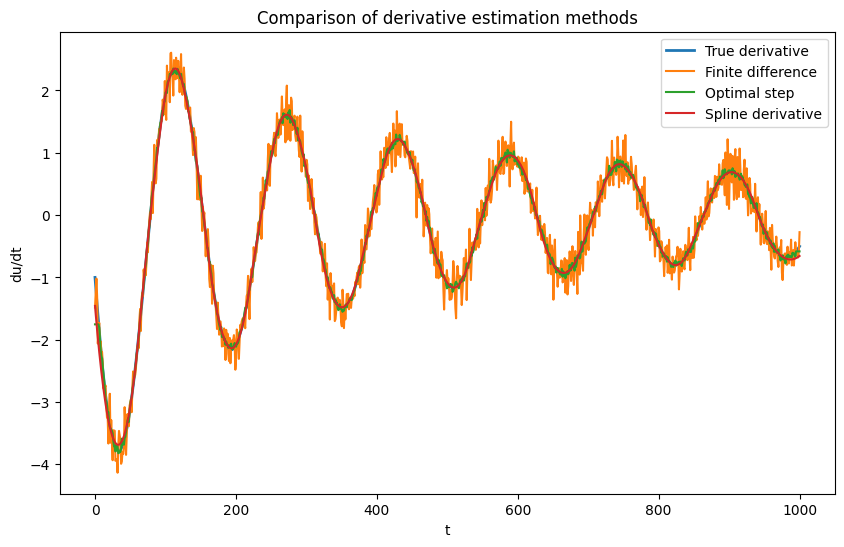